In [2]:
%matplotlib widget
from strategy import CardCounter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from blackjack_py import ProbabilisticRankShoe

In [3]:
# def get_random_incomplete_shoe_counts(n_decks, min_n_cards=0):
#     if min_n_cards > n_decks * 52:
#         raise ValueError("min_n_cards cannot be greater than total cards in shoe")

#     counts = {r: 0 for r in range(2, 12)}
#     while sum(counts.values()) < min_n_cards:
#         for r in range(2, 12):
#             coef = 4 if r != 10 else 16
#             counts[r] = np.random.randint(0, n_decks * coef)
#     return counts


def get_random_incomplete_shoe_counts(n_decks, min_n_cards=0):
    if min_n_cards > n_decks * 52:
        raise ValueError("min_n_cards cannot be greater than total cards in shoe")
    shoe = ProbabilisticRankShoe(n_decks)
    n_cards_to_burn = np.random.randint(0, n_decks * 52 - min_n_cards)
    for _ in range(n_cards_to_burn):
        shoe.sample_and_burn_rank()
    return shoe.get_rank_value_counts()

In [4]:
rank_count = get_random_incomplete_shoe_counts(6, 16)

In [5]:
CardCounter.from_rank_count(rank_count).get_integer_tc()

3

In [6]:
for i in range(100):
    rank_count = get_random_incomplete_shoe_counts(6, 16)
    shoe = " ".join(str(rank_count[c]) for c in range(2, 12))
    print(f"{shoe}")

6 5 2 6 6 2 2 3 13 6
8 14 12 13 11 17 15 14 50 13
1 3 2 1 2 1 2 0 10 2
13 14 16 16 11 15 15 15 59 11
12 12 8 13 14 11 17 13 65 10
20 21 23 21 19 22 21 23 83 19
23 23 23 20 22 23 22 21 85 21
12 14 10 11 7 12 8 9 30 8
20 19 13 13 19 16 17 16 67 15
17 17 15 20 18 19 16 16 68 18
3 2 1 2 0 4 4 1 5 1
18 18 18 22 18 18 19 19 68 19
6 4 9 5 3 7 8 3 18 2
3 2 6 2 6 5 2 6 12 6
6 3 7 2 4 2 7 7 19 6
6 5 4 6 5 5 6 7 28 5
7 4 9 3 8 5 5 5 16 3
6 6 4 3 2 4 5 7 16 2
20 19 20 24 21 20 18 20 81 20
21 19 16 17 14 15 16 22 61 19
6 3 4 5 6 7 1 3 26 6
14 10 7 11 15 11 14 12 49 13
3 1 6 7 2 3 2 5 18 2
14 12 15 10 13 12 9 12 45 10
7 7 3 11 7 13 10 8 30 12
5 6 3 6 3 5 9 4 15 7
11 14 16 16 15 12 15 14 52 12
15 19 19 21 18 19 15 19 70 16
10 14 12 12 16 18 15 10 48 17
4 3 1 3 7 4 5 4 16 1
19 20 21 22 23 18 21 18 81 19
6 1 3 3 4 5 6 1 15 7
13 14 17 13 15 11 18 15 52 12
1 3 3 4 1 3 1 4 9 1
5 5 6 2 1 3 8 2 24 5
9 8 11 6 4 9 11 6 41 7
11 3 8 9 8 6 6 9 25 6
19 21 18 19 19 19 23 17 83 17
19 18 21 18 18 18 20 20 84 19
12 1

In [7]:
true_edge_exec_path = "../build/bin/edge_exec"

In [8]:
results = []

In [9]:
import subprocess
import tqdm

# Start edge_exec in interactive mode (no args)
proc = subprocess.Popen(
    [true_edge_exec_path],
    stdin=subprocess.PIPE,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True,
    bufsize=1  # Line buffered
)

# Read the "Ready..." line
ready_line = proc.stdout.readline()
print(ready_line.strip())

for i in tqdm.tqdm(range(10000)):
    rank_count = get_random_incomplete_shoe_counts(6, 16)
    shoe_args = " ".join(str(rank_count[c]) for c in range(2, 12))
    
    # Send command to the running process
    cmd = f"--best {shoe_args}\n"
    proc.stdin.write(cmd)
    proc.stdin.flush()
    
    # Read the response
    output = proc.stdout.readline().strip()
    
    if output and not output.startswith("Error"):
        # Parse output: "ev, ev_min, ev_max"
        parts = output.split(", ")
        ev, ev_min, ev_max = float(parts[0]), float(parts[1]), float(parts[2])
        tc_int = CardCounter.from_rank_count(rank_count).get_integer_tc()
        tc_float = CardCounter.from_rank_count(rank_count).get_true_count()
        results.append({
            "tc": tc_int,
            "tc_float": tc_float,
            "ev": ev,
            "ev_min": ev_min,
            "ev_max": ev_max,
            "rank_count": rank_count
        })
    else:
        print(f"Error: {output}")

# Clean up - send quit command
proc.stdin.write("quit\n")
proc.stdin.flush()
proc.wait()

print(f"Collected {len(results)} results")

Ready. Enter commands (type 'help' for usage, 'quit' to exit):


  2%|▏         | 157/10000 [20:25<21:21:00,  7.81s/it]


KeyboardInterrupt: 

In [10]:
df = pd.DataFrame(results)

In [11]:
import os

# Expand rank_count dict to individual columns
card_columns = [f"n{r}" for r in range(2, 11)] + ["nA"]
for i, r in enumerate(range(2, 12)):
    col_name = f"n{r}" if r < 11 else "nA"
    df[col_name] = df["rank_count"].apply(lambda x: x[r])

# Drop the rank_count column
df = df.drop(columns=["rank_count"])

csv_path = "true_edge_vs_count_best.csv"
if os.path.exists(csv_path):
    # Append without header
    df.to_csv(csv_path, mode='a', header=False, index=False)
    print(f"Appended {len(df)} rows to existing file")
else:
    df.to_csv(csv_path, index=False)
    print(f"Created new file with {len(df)} rows")

results = []

Appended 157 rows to existing file


In [12]:
df = pd.read_csv("true_edge_vs_count_best.csv") 
print(len(df))

11860


In [ ]:
df

,tc,tc_float,ev,ev_min,ev_max,n2,n3,n4,n5,n6,n7,n8,n9,n10,nA
0,0,0.619048,0.193561,0.193561,0.193618,18,19,21,16,20,20,20,21,78,19
1,7,7.932203,8.050617,8.050617,8.050646,6,3,3,3,5,2,2,6,25,4
2,0,0.838710,1.769864,1.769864,1.769921,6,5,3,4,5,3,7,5,18,6
3,0,-0.497608,-0.099332,-0.099332,-0.099276,15,16,15,16,19,14,16,19,63,16
4,2,2.139918,0.795178,0.795178,0.795247,18,19,14,20,20,20,15,16,81,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10992,1,1.043478,0.301420,0.301419,0.301495,23,21,23,23,24,22,21,22,96,24
10993,-2,-2.212766,0.408811,0.408811,0.408832,6,2,2,4,3,3,8,4,14,1
10994,0,0.000000,1.015479,1.015478,1.015552,4,11,2,4,7,9,8,5,20,8
10995,-1,-1.604938,-0.401582,-0.401582,-0.401511,13,9,19,10,15,9,13,13,46,15


Result type percentages:
  Simple -EV: 5751 (52.30%)
  Simple +EV: 2368 (21.53%)
  Perfect > Count-based: 1624 (14.77%)
  True +EV, Count -EV: 1088 (9.89%)
  True -EV, Count +EV (dangerous): 166 (1.51%)


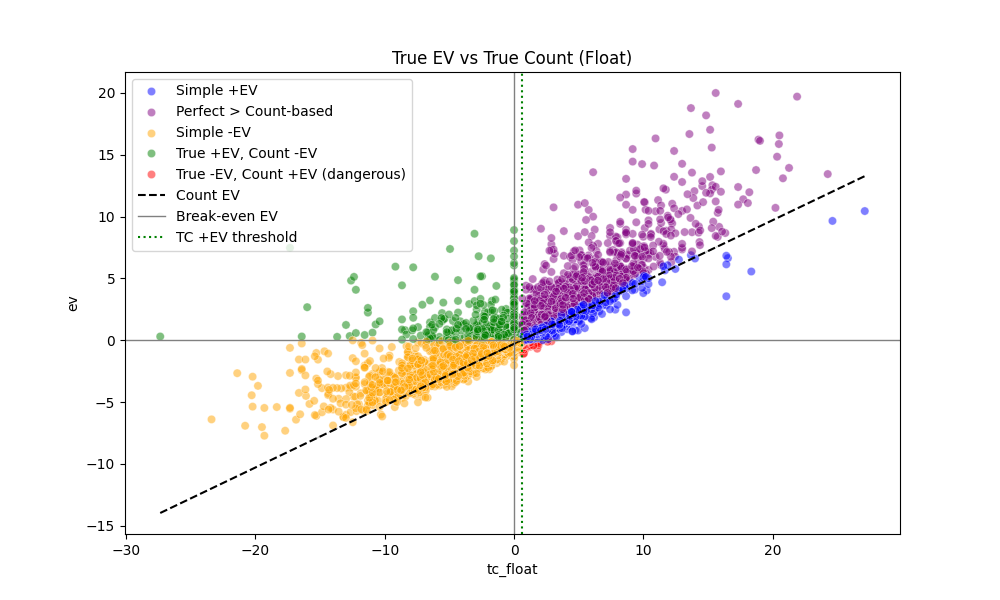

In [ ]:
f, ax = plt.subplots(figsize=(10, 6))

ev_tc_0 = -0.292
ev_for_tc = 0.5
ev_line_x = np.array(df["tc_float"])
ev_line_y = ev_tc_0 + ev_for_tc * ev_line_x

true_ev = df["ev"]

# Classify result types
result_type = np.zeros(len(df), dtype=np.int32)
result_type[true_ev < 0] = 0  # simple -ev
result_type[true_ev > 0] = 1  # simple +ev
result_type[(true_ev > 0) & (ev_line_y < (true_ev - 0.5))] = 2  # true perfect strategy better than count-based one
result_type[(ev_line_y < 0) & (true_ev > 0)] = 3  # true perfect strategy is +ev, but count-based is -ev
result_type[(ev_line_y > 0) & (true_ev < 0)] = 4  # true perfect strategy is -ev, but count-based (incorrectly) promises +ev

# Add result_type to dataframe for plotting
df["result_type"] = result_type

# Map result types to labels
result_labels = {
    0: "Simple -EV",
    1: "Simple +EV",
    2: "Perfect > Count-based",
    3: "True +EV, Count -EV",
    4: "True -EV, Count +EV (dangerous)"
}
df["result_label"] = df["result_type"].map(result_labels)

# Print percentages for each class
print("Result type percentages:")
total = len(df)
for type_id, label in result_labels.items():
    count = (df["result_type"] == type_id).sum()
    pct = 100 * count / total
    print(f"  {label}: {count} ({pct:.2f}%)")

# Color palette for result types
palette = {
    "Simple -EV": "orange",
    "Simple +EV": "blue",
    "Perfect > Count-based": "purple",
    "True +EV, Count -EV": "green",
    "True -EV, Count +EV (dangerous)": "red"
}

sns.scatterplot(data=df, x="tc_float", y="ev", hue="result_label", 
                palette=palette, ax=ax, alpha=0.5)

sns.lineplot(
    x=ev_line_x, y=ev_line_y, color="black", linestyle="--", ax=ax,
    label="Count EV"
)
# horizontal line at y = 0
ax.axhline(0, color="grey", linestyle="-", lw=1, label="Break-even EV")
ax.axvline(0, color="grey", linestyle="-", lw=1)
x_tc_plus_ev = -ev_tc_0 / ev_for_tc
ax.axvline(x_tc_plus_ev, color="green", linestyle=":", label="TC +EV threshold")

ax.set_title("True EV vs True Count (Float)")
ax.legend(loc="upper left")

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Card columns are already in the dataframe (n2-n10, nA)
card_columns = [f"n{r}" for r in range(2, 11)] + ["nA"]

# Create feature matrix
X = df[card_columns].values
y = df["ev"].values

# Fit linear regression
reg = LinearRegression()
reg.fit(X, y)

# Print coefficients
print("Linear Regression: EV = intercept + sum(coef_i * n_cards_i)")
print(f"\nIntercept: {reg.intercept_:.6f}")
print(f"R² score: {reg.score(X, y):.4f}")
print("\nCoefficients (effect on EV per card):")
for col, coef in zip(card_columns, reg.coef_):
    print(f"  {col:>3}: {coef:+.06f}")

Linear Regression: EV = intercept + sum(coef_i * n_cards_i)

Intercept: 1.476606
R² score: 0.5792

Coefficients (effect on EV per card):
   n2: -0.168125
   n3: -0.196700
   n4: -0.270948
   n5: -0.351370
   n6: -0.183323
   n7: -0.137584
   n8: -0.017262
   n9: +0.054961
  n10: +0.215624
   nA: +0.312289


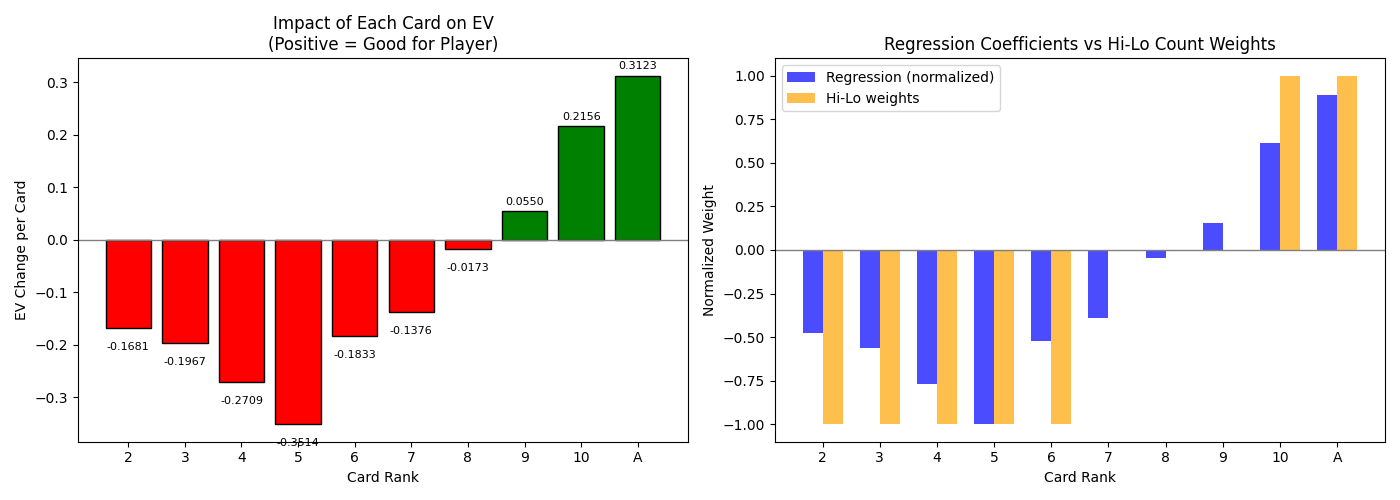

In [ ]:
# Plot 1: Bar chart of coefficients
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Card labels for plotting
card_labels = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "A"]
colors = ["green" if c > 0 else "red" for c in reg.coef_]

ax1 = axes[0]
bars = ax1.bar(card_labels, reg.coef_, color=colors, edgecolor="black")
ax1.axhline(0, color="grey", linestyle="-", lw=1)
ax1.set_xlabel("Card Rank")
ax1.set_ylabel("EV Change per Card")
ax1.set_title("Impact of Each Card on EV\n(Positive = Good for Player)")

# Add value labels on bars
for bar, coef in zip(bars, reg.coef_):
    height = bar.get_height()
    ax1.annotate(f'{coef:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height > 0 else -10),
                textcoords="offset points",
                ha='center', va='bottom' if height > 0 else 'top',
                fontsize=8)

# Plot 2: Compare with Hi-Lo count weights
ax2 = axes[1]
hi_lo_weights = [-1, -1, -1, -1, -1, 0, 0, 0, 1, 1]  # 2-6: +1, 7-9: 0, 10-A: -1

# Normalize coefficients for comparison
coef_normalized = reg.coef_ / np.abs(reg.coef_).max()

x = np.arange(len(card_labels))
width = 0.35

bars1 = ax2.bar(x - width/2, coef_normalized, width, label='Regression (normalized)', color='blue', alpha=0.7)
bars2 = ax2.bar(x + width/2, hi_lo_weights, width, label='Hi-Lo weights', color='orange', alpha=0.7)

ax2.set_xlabel("Card Rank")
ax2.set_ylabel("Normalized Weight")
ax2.set_title("Regression Coefficients vs Hi-Lo Count Weights")
ax2.set_xticks(x)
ax2.set_xticklabels(card_labels)
ax2.legend()
ax2.axhline(0, color="grey", linestyle="-", lw=1)

plt.tight_layout()
plt.show()

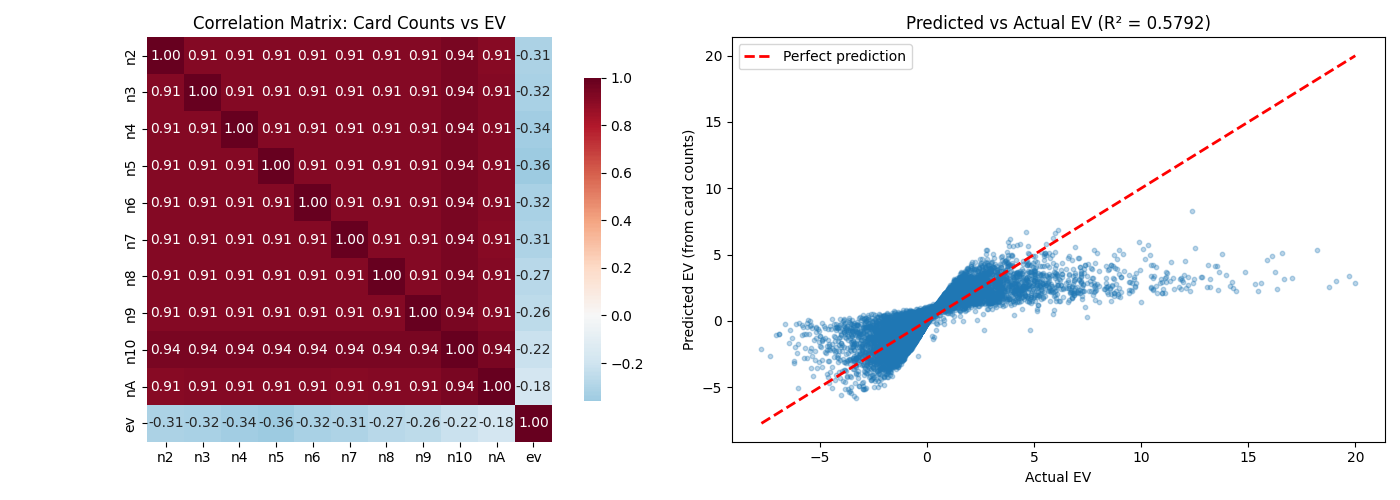

In [ ]:
# Plot 3: Correlation heatmap between card counts and EV
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation matrix
corr_cols = card_columns + ["ev"]
corr_matrix = df[corr_cols].corr()

ax1 = axes[0]
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, 
            ax=ax1, square=True, cbar_kws={"shrink": 0.8})
ax1.set_title("Correlation Matrix: Card Counts vs EV")

# Plot 4: Predicted vs Actual EV
ax2 = axes[1]
y_pred = reg.predict(X)
ax2.scatter(y, y_pred, alpha=0.3, s=10)
ax2.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect prediction')
ax2.set_xlabel("Actual EV")
ax2.set_ylabel("Predicted EV (from card counts)")
ax2.set_title(f"Predicted vs Actual EV (R² = {reg.score(X, y):.4f})")
ax2.legend()

plt.tight_layout()
plt.show()

Linear Regression on Card PROPORTIONS:
R² score: 0.7937

Coefficients (effect on EV per proportion unit):
    2: -9.4243
    3: -13.2176
    4: -22.0982
    5: -29.4061
    6: -11.9779
    7: -9.7052
    8: +4.6642
    9: +12.5384
   10: +32.4370
    A: +46.1896


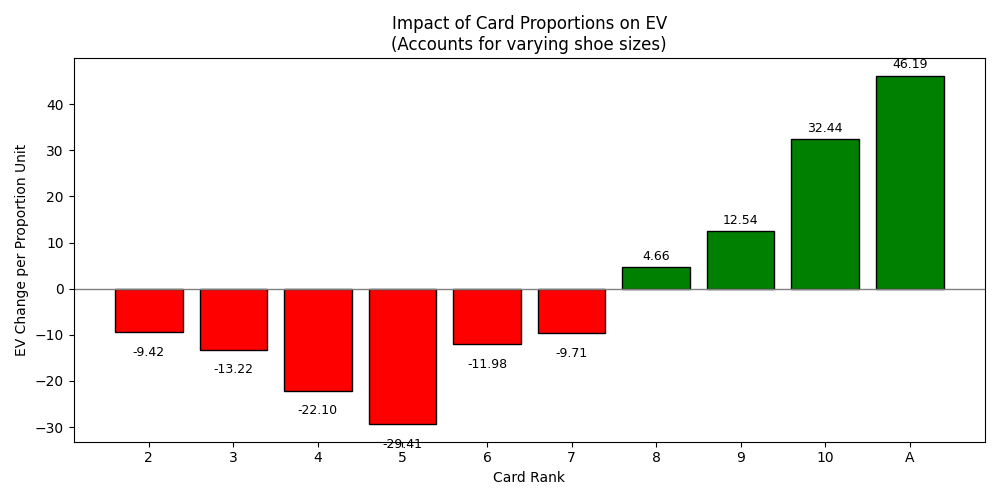

In [ ]:
# Analyze card proportions (normalized by total cards)
df["total_cards"] = df[card_columns].sum(axis=1)

# Create proportion columns
prop_columns = []
for col in card_columns:
    prop_col = f"{col}_prop"
    df[prop_col] = df[col] / df["total_cards"]
    prop_columns.append(prop_col)

# Fit regression on proportions
X_prop = df[prop_columns].values
reg_prop = LinearRegression()
reg_prop.fit(X_prop, y)

print("Linear Regression on Card PROPORTIONS:")
print(f"R² score: {reg_prop.score(X_prop, y):.4f}")
print("\nCoefficients (effect on EV per proportion unit):")
for col, coef in zip(card_labels, reg_prop.coef_):
    print(f"  {col:>3}: {coef:+.4f}")

# Plot proportion coefficients
fig, ax = plt.subplots(figsize=(10, 5))
colors_prop = ["green" if c > 0 else "red" for c in reg_prop.coef_]
bars = ax.bar(card_labels, reg_prop.coef_, color=colors_prop, edgecolor="black")
ax.axhline(0, color="grey", linestyle="-", lw=1)
ax.set_xlabel("Card Rank")
ax.set_ylabel("EV Change per Proportion Unit")
ax.set_title("Impact of Card Proportions on EV\n(Accounts for varying shoe sizes)")

for bar, coef in zip(bars, reg_prop.coef_):
    height = bar.get_height()
    ax.annotate(f'{coef:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height > 0 else -10),
                textcoords="offset points",
                ha='center', va='bottom' if height > 0 else 'top',
                fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

# Calculate predictions
y_pred_counts = reg.predict(X)  # From card counts regression
y_pred_props = reg_prop.predict(X_prop)  # From proportions regression

# Calculate RMSE
rmse_counts = np.sqrt(mean_squared_error(y, y_pred_counts))
rmse_props = np.sqrt(mean_squared_error(y, y_pred_props))

# Also calculate RMSE for simple TC-based linear model
ev_tc_0 = -0.292
ev_for_tc = 0.5
y_pred_tc = ev_tc_0 + ev_for_tc * df["tc_float"].values
rmse_tc = np.sqrt(mean_squared_error(y, y_pred_tc))

print("Root Mean Square Error (RMSE) comparison:")
print(f"  Hi-Lo True Count linear model:  {rmse_tc:.4f}")
print(f"  Card counts regression:         {rmse_counts:.4f}")
print(f"  Card proportions regression:    {rmse_props:.4f}")
print()
print(f"Improvement over TC model:")
print(f"  Card counts:     {100*(rmse_tc - rmse_counts)/rmse_tc:.1f}% lower RMSE")
print(f"  Card proportions: {100*(rmse_tc - rmse_props)/rmse_tc:.1f}% lower RMSE")

Root Mean Square Error (RMSE) comparison:
  Hi-Lo True Count linear model:  1.3156
  Card counts regression:         1.4406
  Card proportions regression:    1.0087

Improvement over TC model:
  Card counts:     -9.5% lower RMSE
  Card proportions: 23.3% lower RMSE


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 1. Try polynomial features on proportions
poly_degrees = [2, 3]
for degree in poly_degrees:
    poly_reg = make_pipeline(PolynomialFeatures(degree, include_bias=False), LinearRegression())
    poly_reg.fit(X_prop, y)
    y_pred_poly = poly_reg.predict(X_prop)
    rmse_poly = np.sqrt(mean_squared_error(y, y_pred_poly))
    r2_poly = poly_reg.score(X_prop, y)
    print(f"Polynomial (degree {degree}) on proportions: RMSE={rmse_poly:.4f}, R²={r2_poly:.4f}")

# 2. Try proportions with interaction terms only (degree 2)
poly_inter = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_inter = poly_inter.fit_transform(X_prop)
reg_inter = LinearRegression()
reg_inter.fit(X_inter, y)
y_pred_inter = reg_inter.predict(X_inter)
rmse_inter = np.sqrt(mean_squared_error(y, y_pred_inter))
print(f"Proportions + interactions: RMSE={rmse_inter:.4f}, R²={reg_inter.score(X_inter, y):.4f}")
print(f"  Number of features: {X_inter.shape[1]}")

Polynomial (degree 2) on proportions: RMSE=0.4181, R²=0.9646
Polynomial (degree 3) on proportions: RMSE=0.1911, R²=0.9926
Proportions + interactions: RMSE=0.4181, R²=0.9646
  Number of features: 55
Polynomial (degree 3) on proportions: RMSE=0.1911, R²=0.9926
Proportions + interactions: RMSE=0.4181, R²=0.9646
  Number of features: 55


In [ ]:
# 3. Compare Hi-Lo's approximation vs true proportional approach
# Hi-Lo divides running count by decks remaining (approximating proportion)

# True count formula: TC = RC / decks_remaining
# This is equivalent to: TC = (sum of weighted cards) / (total_cards / 52)
# Which means: TC ≈ 52 * (weighted_proportion)

# Let's compute a "perfect" true count using optimal weights from regression
# and compare to Hi-Lo

# Hi-Lo running count (before dividing by decks)
hi_lo_weights_arr = np.array([-1, -1, -1, -1, -1, 0, 0, 0, 1, 1])
df["hi_lo_rc"] = (df[card_columns].values * hi_lo_weights_arr).sum(axis=1)
df["hi_lo_tc_approx"] = df["hi_lo_rc"] / (df["total_cards"] / 52)

# Regression-optimal running count
optimal_weights = reg.coef_ / np.abs(reg.coef_).mean()  # normalize
df["optimal_rc"] = (df[card_columns].values * optimal_weights).sum(axis=1)
df["optimal_tc"] = df["optimal_rc"] / (df["total_cards"] / 52)

# Fit linear model on optimal TC
reg_opt_tc = LinearRegression()
reg_opt_tc.fit(df[["optimal_tc"]].values, y)
y_pred_opt_tc = reg_opt_tc.predict(df[["optimal_tc"]].values)
rmse_opt_tc = np.sqrt(mean_squared_error(y, y_pred_opt_tc))

# Fit linear model on Hi-Lo TC (our approximation)
reg_hilo_tc = LinearRegression()
reg_hilo_tc.fit(df[["hi_lo_tc_approx"]].values, y)
y_pred_hilo_tc = reg_hilo_tc.predict(df[["hi_lo_tc_approx"]].values)
rmse_hilo_tc = np.sqrt(mean_squared_error(y, y_pred_hilo_tc))

print("\nTrue Count style models (RC / decks_remaining):")
print(f"  Hi-Lo TC (fitted):     RMSE={rmse_hilo_tc:.4f}, R²={reg_hilo_tc.score(df[['hi_lo_tc_approx']].values, y):.4f}")
print(f"  Optimal-weight TC:     RMSE={rmse_opt_tc:.4f}, R²={reg_opt_tc.score(df[['optimal_tc']].values, y):.4f}")
print(f"\nOptimal TC linear model: EV = {reg_opt_tc.intercept_:.4f} + {reg_opt_tc.coef_[0]:.4f} * TC")
print(f"Hi-Lo TC linear model:   EV = {reg_hilo_tc.intercept_:.4f} + {reg_hilo_tc.coef_[0]:.4f} * TC")


True Count style models (RC / decks_remaining):
  Hi-Lo TC (fitted):     RMSE=1.1941, R²=0.7109
  Optimal-weight TC:     RMSE=1.0151, R²=0.7911

Optimal TC linear model: EV = 1.0899 + 0.4128 * TC
Hi-Lo TC linear model:   EV = 0.2601 + 0.5012 * TC


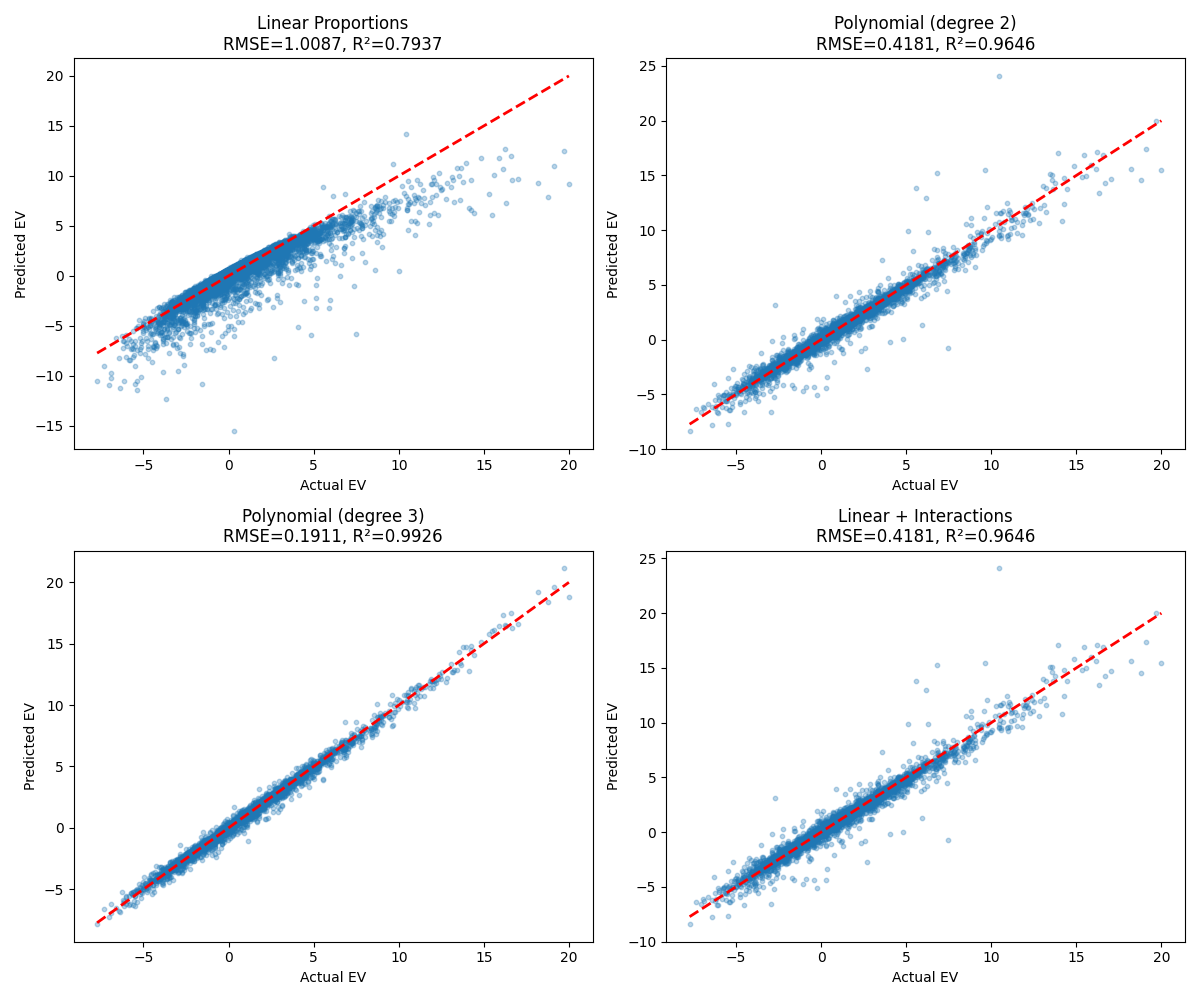

In [ ]:
# Visualize Predicted vs Actual EV for polynomial models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Refit models and store predictions for plotting
poly2_reg = make_pipeline(PolynomialFeatures(2, include_bias=False), LinearRegression())
poly2_reg.fit(X_prop, y)
y_pred_poly2 = poly2_reg.predict(X_prop)
rmse_poly2 = np.sqrt(mean_squared_error(y, y_pred_poly2))
r2_poly2 = poly2_reg.score(X_prop, y)

poly3_reg = make_pipeline(PolynomialFeatures(3, include_bias=False), LinearRegression())
poly3_reg.fit(X_prop, y)
y_pred_poly3 = poly3_reg.predict(X_prop)
rmse_poly3 = np.sqrt(mean_squared_error(y, y_pred_poly3))
r2_poly3 = poly3_reg.score(X_prop, y)

# Plot 1: Linear proportions model
ax1 = axes[0, 0]
ax1.scatter(y, y_pred_props, alpha=0.3, s=10)
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax1.set_xlabel("Actual EV")
ax1.set_ylabel("Predicted EV")
ax1.set_title(f"Linear Proportions\nRMSE={rmse_props:.4f}, R²={reg_prop.score(X_prop, y):.4f}")

# Plot 2: Polynomial degree 2
ax2 = axes[0, 1]
ax2.scatter(y, y_pred_poly2, alpha=0.3, s=10)
ax2.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax2.set_xlabel("Actual EV")
ax2.set_ylabel("Predicted EV")
ax2.set_title(f"Polynomial (degree 2)\nRMSE={rmse_poly2:.4f}, R²={r2_poly2:.4f}")

# Plot 3: Polynomial degree 3
ax3 = axes[1, 0]
ax3.scatter(y, y_pred_poly3, alpha=0.3, s=10)
ax3.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax3.set_xlabel("Actual EV")
ax3.set_ylabel("Predicted EV")
ax3.set_title(f"Polynomial (degree 3)\nRMSE={rmse_poly3:.4f}, R²={r2_poly3:.4f}")

# Plot 4: Interactions only
ax4 = axes[1, 1]
ax4.scatter(y, y_pred_inter, alpha=0.3, s=10)
ax4.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax4.set_xlabel("Actual EV")
ax4.set_ylabel("Predicted EV")
ax4.set_title(f"Linear + Interactions\nRMSE={rmse_inter:.4f}, R²={reg_inter.score(X_inter, y):.4f}")

plt.tight_layout()
plt.show()

In [ ]:
# Analyze which interaction terms matter most
feature_names = poly_inter.get_feature_names_out(prop_columns)
interaction_coefs = list(zip(feature_names, reg_inter.coef_))

# Sort by absolute coefficient value
interaction_coefs_sorted = sorted(interaction_coefs, key=lambda x: abs(x[1]), reverse=True)

print("Top 20 most important features (proportions + interactions):")
print("-" * 50)
for name, coef in interaction_coefs_sorted[:20]:
    # Clean up names for readability
    name_clean = name.replace("_prop", "")
    print(f"  {name_clean:30s}: {coef:+.4f}")

# Identify pure interaction terms (not single features)
print("\nTop 10 pure interaction terms:")
print("-" * 50)
interactions_only = [(n, c) for n, c in interaction_coefs_sorted if " " in n]
for name, coef in interactions_only[:10]:
    name_clean = name.replace("_prop", "")
    print(f"  {name_clean:30s}: {coef:+.4f}")

Top 20 most important features (proportions + interactions):
--------------------------------------------------
  n8 nA                         : -284.2375
  n3 n6                         : -284.0445
  n9 nA                         : -272.3038
  n6 nA                         : -266.4856
  n5 n6                         : -251.4537
  n2 n6                         : -250.7579
  n7 n10                        : -246.6869
  n7 nA                         : -246.6286
  n8 n10                        : -230.0042
  n6 n9                         : -226.3725
  n6 n8                         : -223.8569
  n6 n10                        : -219.7224
  n4 n6                         : -209.3334
  n4 n9                         : -197.3024
  n7 n9                         : -192.8609
  n5 n9                         : -188.1431
  n2 n5                         : -187.8640
  n4 n8                         : -187.3619
  n5 n10                        : -186.4239
  n3 n8                         : -184.0750

Top 10 

In [ ]:
from scipy import stats

def calculate_model_stats(y_true, y_pred, n_features, model_name):
    """Calculate adjusted R², AIC, BIC for a model"""
    n = len(y_true)
    k = n_features + 1  # +1 for intercept
    
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    
    r2 = 1 - ss_res / ss_tot
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)
    
    # AIC and BIC (using log-likelihood approximation)
    mse = ss_res / n
    log_likelihood = -n/2 * (np.log(2 * np.pi * mse) + 1)
    aic = 2 * k - 2 * log_likelihood
    bic = k * np.log(n) - 2 * log_likelihood
    
    return {
        "model": model_name,
        "n_features": n_features,
        "R²": r2,
        "Adj R²": adj_r2,
        "AIC": aic,
        "BIC": bic,
        "RMSE": np.sqrt(mse)
    }

# Calculate stats for all models
models_stats = []

# 1. Linear proportions (10 features)
models_stats.append(calculate_model_stats(y, y_pred_props, 10, "Linear Proportions"))

# 2. Polynomial degree 2 (65 features)
n_feat_poly2 = PolynomialFeatures(2, include_bias=False).fit_transform(X_prop[:1]).shape[1]
models_stats.append(calculate_model_stats(y, y_pred_poly2, n_feat_poly2, "Polynomial (deg 2)"))

# 3. Polynomial degree 3 (220 features)
n_feat_poly3 = PolynomialFeatures(3, include_bias=False).fit_transform(X_prop[:1]).shape[1]
models_stats.append(calculate_model_stats(y, y_pred_poly3, n_feat_poly3, "Polynomial (deg 3)"))

# 4. Linear + Interactions (55 features)
models_stats.append(calculate_model_stats(y, y_pred_inter, X_inter.shape[1], "Linear + Interactions"))

# Display as DataFrame
stats_df = pd.DataFrame(models_stats)
stats_df = stats_df.set_index("model")
print("Model Comparison (lower AIC/BIC = better, higher Adj R² = better):")
print("=" * 80)
print(stats_df.to_string())

# F-test: compare nested models (linear vs polynomial)
print("\n" + "=" * 80)
print("F-test: Linear Proportions vs Polynomial (deg 2)")
print("-" * 50)

n = len(y)
ss_res_reduced = np.sum((y - y_pred_props) ** 2)
ss_res_full = np.sum((y - y_pred_poly2) ** 2)
df_reduced = n - 10 - 1
df_full = n - n_feat_poly2 - 1
df_diff = df_reduced - df_full

f_stat = ((ss_res_reduced - ss_res_full) / df_diff) / (ss_res_full / df_full)
p_value = 1 - stats.f.cdf(f_stat, df_diff, df_full)

print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.2e}")
print(f"Conclusion: {'Polynomial model significantly better' if p_value < 0.05 else 'Linear model sufficient'}")

Model Comparison (lower AIC/BIC = better, higher Adj R² = better):
                       n_features        R²    Adj R²           AIC           BIC      RMSE
model                                                                                      
Linear Proportions             10  0.793709  0.793502  31419.782271  31500.141427  1.008660
Polynomial (deg 2)             65  0.964562  0.964348  12158.371809  12640.526743  0.418058
Polynomial (deg 3)            285  0.992592  0.992395  -4614.828052  -2525.490005  0.191136
Linear + Interactions          55  0.964562  0.964381  12138.371809  12547.472965  0.418058

F-test: Linear Proportions vs Polynomial (deg 2)
--------------------------------------------------
F-statistic: 958.2047
p-value: 1.11e-16
Conclusion: Polynomial model significantly better


In [ ]:
from scipy import stats

def f_test(y_true, y_pred_reduced, y_pred_full, df_reduced, df_full):
    """
    Perform F-test comparing nested models.
    Returns F-statistic and p-value.
    """
    n = len(y_true)
    ss_res_reduced = np.sum((y_true - y_pred_reduced) ** 2)
    ss_res_full = np.sum((y_true - y_pred_full) ** 2)
    
    df_diff = df_reduced - df_full
    
    f_stat = ((ss_res_reduced - ss_res_full) / df_diff) / (ss_res_full / df_full)
    p_value = 1 - stats.f.cdf(f_stat, df_diff, df_full)
    
    return f_stat, p_value

n = len(y)

# Model degrees of freedom (n - k - 1, where k = number of features)
n_feat_linear = 10
n_feat_inter = X_inter.shape[1]  # 55 (10 linear + 45 interactions)
n_feat_poly2 = PolynomialFeatures(2, include_bias=False).fit_transform(X_prop[:1]).shape[1]  # 65
n_feat_poly3 = PolynomialFeatures(3, include_bias=False).fit_transform(X_prop[:1]).shape[1]  # 285

df_linear = n - n_feat_linear - 1
df_inter = n - n_feat_inter - 1
df_poly2 = n - n_feat_poly2 - 1
df_poly3 = n - n_feat_poly3 - 1

print("F-test Chain: Comparing Nested Models")
print("=" * 70)
print(f"{'Model':<25} {'Features':>10} {'df':>10}")
print("-" * 70)
print(f"{'Linear':<25} {n_feat_linear:>10} {df_linear:>10}")
print(f"{'Linear + Interactions':<25} {n_feat_inter:>10} {df_inter:>10}")
print(f"{'Polynomial (deg 2)':<25} {n_feat_poly2:>10} {df_poly2:>10}")
print(f"{'Polynomial (deg 3)':<25} {n_feat_poly3:>10} {df_poly3:>10}")
print()

# Test 1: Linear -> Linear + Interactions
f1, p1 = f_test(y, y_pred_props, y_pred_inter, df_linear, df_inter)
print(f"Test 1: Linear → Linear + Interactions")
print(f"  F-statistic: {f1:.4f}, p-value: {p1:.2e}")
print(f"  {'✓ Interactions significantly improve model' if p1 < 0.05 else '✗ Interactions not significant'}")
print()

# Test 2: Linear + Interactions -> Polynomial (deg 2)
f2, p2 = f_test(y, y_pred_inter, y_pred_poly2, df_inter, df_poly2)
print(f"Test 2: Linear + Interactions → Polynomial (deg 2)")
print(f"  F-statistic: {f2:.4f}, p-value: {p2:.2e}")
print(f"  {'✓ Squared terms significantly improve model' if p2 < 0.05 else '✗ Squared terms not significant'}")
print()

# Test 2.1: Linear + Interactions -> Polynomial (deg 3) - direct jump
f2_1, p2_1 = f_test(y, y_pred_inter, y_pred_poly3, df_inter, df_poly3)
print(f"Test 2.1: Linear + Interactions → Polynomial (deg 3) [direct jump]")
print(f"  F-statistic: {f2_1:.4f}, p-value: {p2_1:.2e}")
print(f"  {'✓ Cubic model significantly improves over interactions' if p2_1 < 0.05 else '✗ Cubic model not significantly better'}")
print()

# Test 3: Polynomial (deg 2) -> Polynomial (deg 3)
f3, p3 = f_test(y, y_pred_poly2, y_pred_poly3, df_poly2, df_poly3)
print(f"Test 3: Polynomial (deg 2) → Polynomial (deg 3)")
print(f"  F-statistic: {f3:.4f}, p-value: {p3:.2e}")
print(f"  {'✓ Cubic terms significantly improve model' if p3 < 0.05 else '✗ Cubic terms not significant'}")
print()

# Summary
print("=" * 70)
print("Summary: Recommended model based on F-tests (α=0.05):")
if p1 >= 0.05:
    print("  → Linear Proportions (simplest adequate model)")
elif p2_1 < 0.05:
    # Direct jump from interactions to cubic is significant
    print("  → Polynomial (degree 3) - cubic terms add value over interactions")
elif p2 >= 0.05:
    print("  → Linear + Interactions")
elif p3 >= 0.05:
    print("  → Polynomial (degree 2)")
else:
    print("  → Polynomial (degree 3)")

F-test Chain: Comparing Nested Models
Model                       Features         df
----------------------------------------------------------------------
Linear                            10      10986
Linear + Interactions             55      10941
Polynomial (deg 2)                65      10931
Polynomial (deg 3)               285      10711

Test 1: Linear → Linear + Interactions
  F-statistic: 1172.2104, p-value: 1.11e-16
  ✓ Interactions significantly improve model

Test 2: Linear + Interactions → Polynomial (deg 2)
  F-statistic: -0.0000, p-value: 1.00e+00
  ✗ Squared terms not significant

Test 2.1: Linear + Interactions → Polynomial (deg 3) [direct jump]
  F-statistic: 176.2162, p-value: 1.11e-16
  ✓ Cubic model significantly improves over interactions

Test 3: Polynomial (deg 2) → Polynomial (deg 3)
  F-statistic: 184.2260, p-value: 1.11e-16
  ✓ Cubic terms significantly improve model

Summary: Recommended model based on F-tests (α=0.05):
  → Polynomial (degree 3) - cubic t

In [ ]:
# Cross-validation to check for overfitting
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear": make_pipeline(LinearRegression()),
    "Linear + Interactions": make_pipeline(
        PolynomialFeatures(2, interaction_only=True, include_bias=False), 
        LinearRegression()
    ),
    "Polynomial (deg 2)": make_pipeline(
        PolynomialFeatures(2, include_bias=False), 
        LinearRegression()
    ),
    "Polynomial (deg 3)": make_pipeline(
        PolynomialFeatures(3, include_bias=False), 
        LinearRegression()
    ),
}

print("Cross-Validation Results (5-fold)")
print("=" * 70)
print(f"{'Model':<25} {'Train R²':>12} {'CV R² (mean)':>14} {'CV R² (std)':>12} {'Overfit?':>10}")
print("-" * 70)

for name, model in models.items():
    # Fit on full data for train score
    model.fit(X_prop, y)
    train_r2 = model.score(X_prop, y)
    
    # Cross-validation scores
    cv_scores = cross_val_score(model, X_prop, y, cv=kf, scoring='r2')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # Check for significant overfit (train >> CV)
    overfit = "⚠️ YES" if (train_r2 - cv_mean) > 0.02 else "No"
    
    print(f"{name:<25} {train_r2:>12.4f} {cv_mean:>14.4f} {cv_std:>12.4f} {overfit:>10}")

print()
print("Note: Large gap between Train R² and CV R² indicates overfitting.")
print("      High CV std indicates unstable model.")

# Also compute CV RMSE for practical comparison
print("\n" + "=" * 70)
print("Cross-Validation RMSE")
print("-" * 70)
for name, model in models.items():
    cv_rmse = -cross_val_score(model, X_prop, y, cv=kf, scoring='neg_root_mean_squared_error')
    print(f"{name:<25}: {cv_rmse.mean():.4f} ± {cv_rmse.std():.4f}")

Cross-Validation Results (5-fold)
Model                         Train R²   CV R² (mean)  CV R² (std)   Overfit?
----------------------------------------------------------------------
Linear                          0.7937         0.7916       0.0216         No
Linear + Interactions           0.9646         0.9603       0.0068         No
Linear + Interactions           0.9646         0.9603       0.0068         No
Polynomial (deg 2)              0.9646         0.9603       0.0068         No
Polynomial (deg 2)              0.9646         0.9603       0.0068         No
Polynomial (deg 3)              0.9926         0.9855       0.0034         No

Note: Large gap between Train R² and CV R² indicates overfitting.
      High CV std indicates unstable model.

Cross-Validation RMSE
----------------------------------------------------------------------
Linear                   : 1.0114 ± 0.0560
Linear + Interactions    : 0.4403 ± 0.0408
Polynomial (deg 3)              0.9926         0.9855     

KNeighborsRegressor Performance (on scaled proportions)
    k     Train R²   CV R² (mean)  CV R² (std)      CV RMSE
----------------------------------------------------------------------
    1       1.0000         0.7536       0.0305       1.0983
    1       1.0000         0.7536       0.0305       1.0983
    3       1.0000         0.8292       0.0119       0.9163
    3       1.0000         0.8292       0.0119       0.9163
    5       1.0000         0.8275       0.0124       0.9209
    5       1.0000         0.8275       0.0124       0.9209
   10       1.0000         0.8098       0.0121       0.9669
   10       1.0000         0.8098       0.0121       0.9669
   15       1.0000         0.7958       0.0091       1.0023
   15       1.0000         0.7958       0.0091       1.0023
   20       1.0000         0.7809       0.0061       1.0387
   20       1.0000         0.7809       0.0061       1.0387
   30       1.0000         0.7561       0.0053       1.0959
   30       1.0000         0.7561

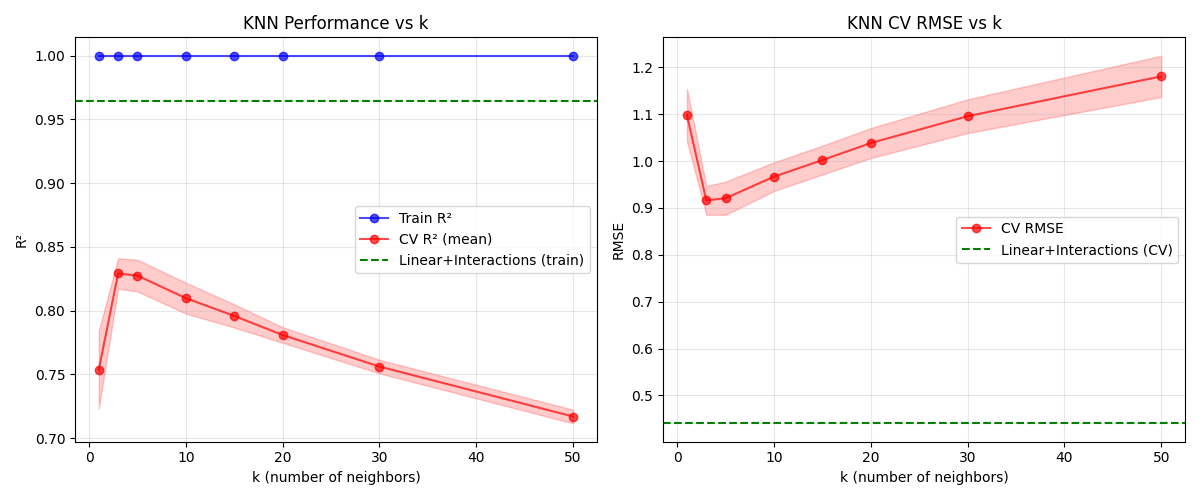

In [ ]:
# KNeighborsRegressor comparison
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Scale features for KNN (important for distance-based methods)
scaler = StandardScaler()
X_prop_scaled = scaler.fit_transform(X_prop)

# Try different values of k
k_values = [1, 3, 5, 10, 15, 20, 30, 50]
knn_results = []

print("KNeighborsRegressor Performance (on scaled proportions)")
print("=" * 70)
print(f"{'k':>5} {'Train R²':>12} {'CV R² (mean)':>14} {'CV R² (std)':>12} {'CV RMSE':>12}")
print("-" * 70)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k, weights="distance")
    
    # Train score
    knn.fit(X_prop_scaled, y)
    train_r2 = knn.score(X_prop_scaled, y)
    
    # CV scores
    cv_r2 = cross_val_score(knn, X_prop_scaled, y, cv=kf, scoring='r2')
    cv_rmse = -cross_val_score(knn, X_prop_scaled, y, cv=kf, scoring='neg_root_mean_squared_error')
    
    knn_results.append({
        'k': k,
        'train_r2': train_r2,
        'cv_r2_mean': cv_r2.mean(),
        'cv_r2_std': cv_r2.std(),
        'cv_rmse_mean': cv_rmse.mean(),
        'cv_rmse_std': cv_rmse.std()
    })
    
    print(f"{k:>5} {train_r2:>12.4f} {cv_r2.mean():>14.4f} {cv_r2.std():>12.4f} {cv_rmse.mean():>12.4f}")

# Find best k
best_knn = max(knn_results, key=lambda x: x['cv_r2_mean'])
print(f"\nBest k = {best_knn['k']} (CV R² = {best_knn['cv_r2_mean']:.4f})")

# Compare with linear models
print("\n" + "=" * 70)
print("Comparison: KNN vs Linear Models")
print("-" * 70)

# Best KNN
knn_best = KNeighborsRegressor(n_neighbors=best_knn['k'])
cv_rmse_knn = -cross_val_score(knn_best, X_prop_scaled, y, cv=kf, scoring='neg_root_mean_squared_error')

# Linear + Interactions (our recommended model)
linear_inter = make_pipeline(
    PolynomialFeatures(2, interaction_only=True, include_bias=False), 
    LinearRegression()
)
cv_rmse_inter = -cross_val_score(linear_inter, X_prop, y, cv=kf, scoring='neg_root_mean_squared_error')

# Simple Linear
linear_simple = LinearRegression()
cv_rmse_linear = -cross_val_score(linear_simple, X_prop, y, cv=kf, scoring='neg_root_mean_squared_error')

print(f"{'Model':<30} {'CV RMSE':>15}")
print("-" * 50)
print(f"{'Linear Proportions':<30} {cv_rmse_linear.mean():>10.4f} ± {cv_rmse_linear.std():.4f}")
print(f"{'Linear + Interactions':<30} {cv_rmse_inter.mean():>10.4f} ± {cv_rmse_inter.std():.4f}")
best_knn["k"]
print(f"{f'KNN (k={k})':<30} {cv_rmse_knn.mean():>10.4f} ± {cv_rmse_knn.std():.4f}")

# Plot k vs performance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

knn_df = pd.DataFrame(knn_results)

# Plot 1: R² vs k
ax1 = axes[0]
ax1.plot(knn_df['k'], knn_df['train_r2'], 'b-o', label='Train R²', alpha=0.7)
ax1.plot(knn_df['k'], knn_df['cv_r2_mean'], 'r-o', label='CV R² (mean)', alpha=0.7)
ax1.fill_between(knn_df['k'], 
                  knn_df['cv_r2_mean'] - knn_df['cv_r2_std'],
                  knn_df['cv_r2_mean'] + knn_df['cv_r2_std'],
                  color='red', alpha=0.2)
ax1.axhline(reg_inter.score(X_inter, y), color='green', linestyle='--', label='Linear+Interactions (train)')
ax1.set_xlabel('k (number of neighbors)')
ax1.set_ylabel('R²')
ax1.set_title('KNN Performance vs k')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: RMSE vs k
ax2 = axes[1]
ax2.plot(knn_df['k'], knn_df['cv_rmse_mean'], 'r-o', label='CV RMSE', alpha=0.7)
ax2.fill_between(knn_df['k'], 
                  knn_df['cv_rmse_mean'] - knn_df['cv_rmse_std'],
                  knn_df['cv_rmse_mean'] + knn_df['cv_rmse_std'],
                  color='red', alpha=0.2)
ax2.axhline(cv_rmse_inter.mean(), color='green', linestyle='--', label='Linear+Interactions (CV)')
ax2.set_xlabel('k (number of neighbors)')
ax2.set_ylabel('RMSE')
ax2.set_title('KNN CV RMSE vs k')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Comparing Multiple Regression Methods
Model                       CV R² (mean)  CV R² (std)      CV RMSE   RMSE std
--------------------------------------------------------------------------------
Linear                            0.7916       0.0216       1.0114     0.0560
Linear + Interactions             0.9603       0.0068       0.4403     0.0408
Ridge (α=1)                       0.7763       0.0195       1.0483     0.0508
Lasso (α=0.01)                    0.6171       0.0202       1.3723     0.0431
Ridge (α=1)                       0.7763       0.0195       1.0483     0.0508
Lasso (α=0.01)                    0.6171       0.0202       1.3723     0.0431
Random Forest                     0.9014       0.0106       0.6950     0.0263
Random Forest                     0.9014       0.0106       0.6950     0.0263
Gradient Boosting                 0.9606       0.0058       0.4387     0.0254
Gradient Boosting                 0.9606       0.0058       0.4387     0.0254
MLP (100,50)           

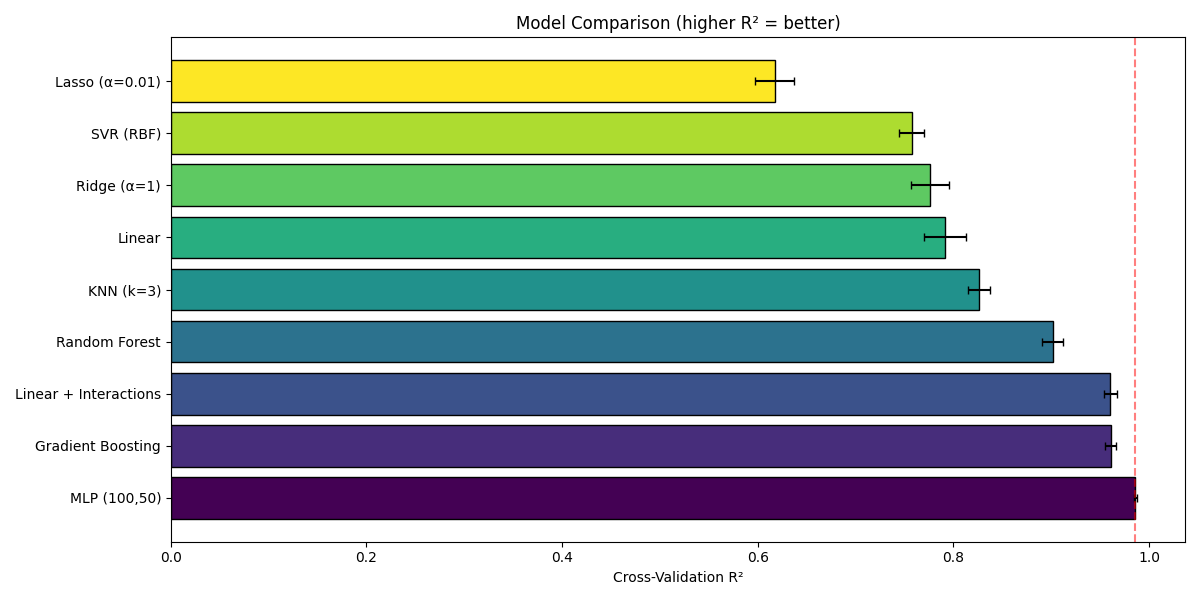

In [ ]:
# Compare multiple regression methods
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define models to compare
models = {
    # Linear models
    "Linear": LinearRegression(),
    "Linear + Interactions": make_pipeline(
        PolynomialFeatures(2, interaction_only=True, include_bias=False),
        LinearRegression()
    ),
    "Ridge (α=1)": Ridge(alpha=1.0),
    "Lasso (α=0.01)": Lasso(alpha=0.01),
    
    # Tree-based (capture non-linear relationships, feature interactions)
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    
    # Neural network (can learn complex patterns)
    "MLP (100,50)": make_pipeline(
        StandardScaler(),
        MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42, early_stopping=True)
    ),
    
    # Support Vector Regression (good for medium-sized data)
    "SVR (RBF)": make_pipeline(StandardScaler(), SVR(kernel='rbf', C=1.0)),
    
    # KNN for reference
    f"KNN (k={best_knn['k']})": make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=best_knn['k'])),
}

print("Comparing Multiple Regression Methods")
print("=" * 80)
print(f"{'Model':<25} {'CV R² (mean)':>14} {'CV R² (std)':>12} {'CV RMSE':>12} {'RMSE std':>10}")
print("-" * 80)

results_all = []
for name, model in models.items():
    cv_r2 = cross_val_score(model, X_prop, y, cv=kf, scoring='r2')
    cv_rmse = -cross_val_score(model, X_prop, y, cv=kf, scoring='neg_root_mean_squared_error')
    
    results_all.append({
        'model': name,
        'cv_r2_mean': cv_r2.mean(),
        'cv_r2_std': cv_r2.std(),
        'cv_rmse_mean': cv_rmse.mean(),
        'cv_rmse_std': cv_rmse.std()
    })
    
    print(f"{name:<25} {cv_r2.mean():>14.4f} {cv_r2.std():>12.4f} {cv_rmse.mean():>12.4f} {cv_rmse.std():>10.4f}")

# Sort by CV R²
results_df = pd.DataFrame(results_all).sort_values('cv_r2_mean', ascending=False)
print("\n" + "=" * 80)
print("Ranking by CV R²:")
for i, row in results_df.iterrows():
    print(f"  {row['model']:<25}: R²={row['cv_r2_mean']:.4f}, RMSE={row['cv_rmse_mean']:.4f}")

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(results_df)))
bars = ax.barh(results_df['model'], results_df['cv_r2_mean'], xerr=results_df['cv_r2_std'], 
               color=colors, edgecolor='black', capsize=3)
ax.set_xlabel('Cross-Validation R²')
ax.set_title('Model Comparison (higher R² = better)')
ax.axvline(results_df['cv_r2_mean'].max(), color='red', linestyle='--', alpha=0.5, label='Best')
plt.tight_layout()
plt.show()

Card Importance (Linear + Interactions model)
Accounts for main effects + all interaction contributions
   10:  18.8% █████████
    6:  11.6% █████
    8:   9.9% ████
    A:   9.3% ████
    5:   8.9% ████
    7:   8.7% ████
    9:   8.5% ████
    4:   8.4% ████
    3:   8.1% ████
    2:   7.9% ███

Comparison: Simple Linear vs Interactions Model
--------------------------------------------------
Card     Simple Linear  With Interactions
--------------------------------------------------
2                 4.5%               7.9%
3                 6.2%               8.1%
4                10.2%               8.4%
5                13.6%               8.9%
6                 5.7%              11.6%
7                 4.4%               8.7%
8                 2.1%               9.9%
9                 5.8%               8.5%
10               25.9%              18.8%
A                21.7%               9.3%


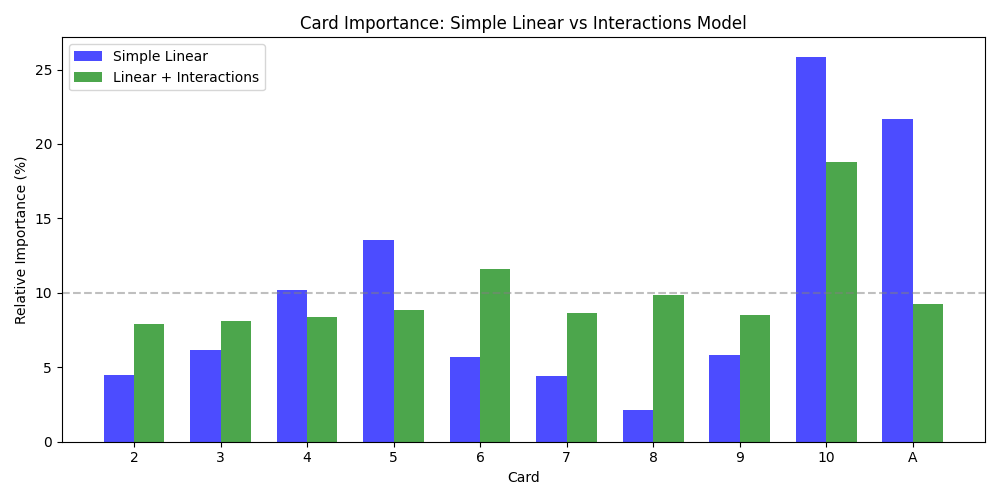


Interpretation: Higher % = card proportion has more influence on EV prediction
The interactions model may shift importance between cards as it captures synergies.


In [ ]:
# Practical interpretability: Aggregate feature importance by card
# For the interactions model, we can compute how much each CARD matters
# by summing contributions from its main effect + all its interactions

# Refit interactions model
poly_inter = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_inter = poly_inter.fit_transform(X_prop)
reg_inter = LinearRegression()
reg_inter.fit(X_inter, y)

feature_names = poly_inter.get_feature_names_out(prop_columns)
coefs = reg_inter.coef_

# For each card, compute its "total influence" considering typical variation
# Weight by the standard deviation of each feature (how much it varies)
feature_stds = X_inter.std(axis=0)
weighted_importance = np.abs(coefs) * feature_stds

# Map each feature to the cards it involves
card_importance = {card: 0.0 for card in card_labels}
for fname, importance in zip(feature_names, weighted_importance):
    fname_clean = fname.replace("_prop", "")
    for i, card in enumerate(card_labels):
        card_pattern = f"n{i+2}" if i < 9 else "nA"
        if card_pattern in fname_clean:
            card_importance[card] += importance

# Normalize to sum to 100%
total = sum(card_importance.values())
card_importance_pct = {k: 100*v/total for k, v in card_importance.items()}

print("Card Importance (Linear + Interactions model)")
print("Accounts for main effects + all interaction contributions")
print("=" * 50)
for card, pct in sorted(card_importance_pct.items(), key=lambda x: -x[1]):
    bar = "█" * int(pct / 2)
    print(f"  {card:>3}: {pct:5.1f}% {bar}")

# Compare with simple linear model importance
simple_importance = np.abs(reg_prop.coef_) * X_prop.std(axis=0)
simple_importance_pct = 100 * simple_importance / simple_importance.sum()

print("\n" + "=" * 50)
print("Comparison: Simple Linear vs Interactions Model")
print("-" * 50)
print(f"{'Card':<6} {'Simple Linear':>15} {'With Interactions':>18}")
print("-" * 50)
for i, card in enumerate(card_labels):
    print(f"{card:<6} {simple_importance_pct[i]:>14.1f}% {card_importance_pct[card]:>17.1f}%")

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(card_labels))
width = 0.35
bars1 = ax.bar(x - width/2, simple_importance_pct, width, label='Simple Linear', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, [card_importance_pct[c] for c in card_labels], width, 
               label='Linear + Interactions', color='green', alpha=0.7)
ax.set_xlabel('Card')
ax.set_ylabel('Relative Importance (%)')
ax.set_title('Card Importance: Simple Linear vs Interactions Model')
ax.set_xticks(x)
ax.set_xticklabels(card_labels)
ax.legend()
ax.axhline(10, color='grey', linestyle='--', alpha=0.5, label='Uniform (10%)')
plt.tight_layout()
plt.show()

print("\nInterpretation: Higher % = card proportion has more influence on EV prediction")
print("The interactions model may shift importance between cards as it captures synergies.")

Axis Definitions:
X-axis: Hi-Lo True Count
  Formula: (Σ high_cards - Σ low_cards) / decks_remaining
  2-6: -1, 7-9: 0, 10-A: +1

Y-axis: 'Side Count' (what Hi-Lo misses)
  Linear combination of card proportions that best predicts
  the residual error from Hi-Lo's EV prediction

Side Count coefficients (effect not captured by Hi-Lo):
  2: +8.82
  3: +5.03
  4: -3.85
  5: -11.16
  6: +6.27
  7: -17.52
  8: -3.15
  9: +4.72
  10: -1.45
  A: +12.31


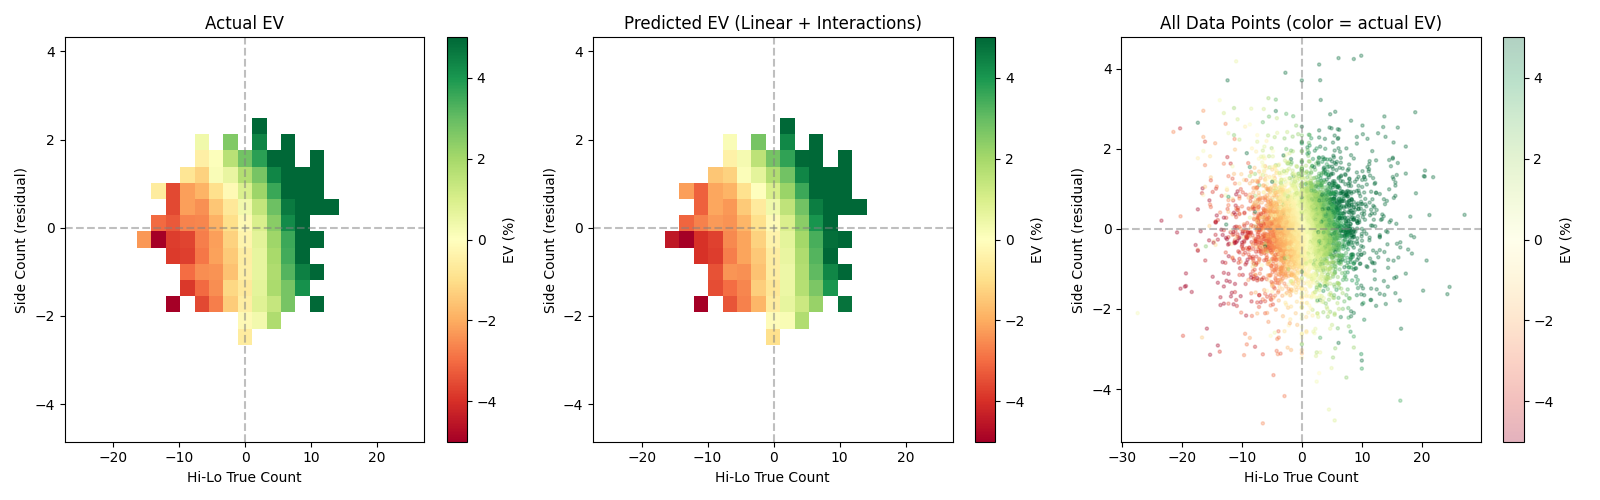


Correlation between Hi-Lo TC and Side Count: 0.000
(Should be ~0 since Side Count captures orthogonal information)

Interpretation:
- Horizontal movement: Standard card counting (Hi-Lo)
- Vertical movement: Additional info Hi-Lo misses (ace/ten composition, etc)
- Green = +EV, Red = -EV


In [ ]:
# Visualize Linear+Interactions model on 2D heatmap using MEANINGFUL axes
# Instead of PCA (which is arbitrary for random data), use:
#   X-axis: Hi-Lo True Count (the standard card counting metric)
#   Y-axis: "Ace-richness" or another meaningful secondary metric

# Refit the interactions model
poly_inter = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_inter = poly_inter.fit_transform(X_prop)
reg_inter = LinearRegression()
reg_inter.fit(X_inter, y)
y_pred_inter = reg_inter.predict(X_inter)

# Axis 1: Hi-Lo True Count (already computed)
# Hi-Lo weights: 2-6 = -1, 7-9 = 0, 10-A = +1
hi_lo_weights = np.array([-1, -1, -1, -1, -1, 0, 0, 0, 1, 1])
hi_lo_tc = (df[card_columns].values * hi_lo_weights).sum(axis=1) / (df["total_cards"].values / 52)

# Axis 2: "Ace-richness" - proportion of Aces relative to 10s
# This captures info Hi-Lo misses (both 10 and A are +1 in Hi-Lo, but they matter differently)
ace_richness = df["nA_prop"].values - df["n10_prop"].values / 4  # Normalize by expected ratio

# Alternative Axis 2: "Side count" - residual not captured by Hi-Lo
# Use regression to find what Hi-Lo misses
reg_hilo = LinearRegression()
reg_hilo.fit(hi_lo_tc.reshape(-1, 1), y)
residual_from_hilo = y - reg_hilo.predict(hi_lo_tc.reshape(-1, 1))

# Fit a model to predict this residual from card proportions
reg_residual = LinearRegression()
reg_residual.fit(X_prop, residual_from_hilo)
side_count = reg_residual.predict(X_prop)  # What Hi-Lo misses

print("Axis Definitions:")
print("=" * 70)
print("X-axis: Hi-Lo True Count")
print("  Formula: (Σ high_cards - Σ low_cards) / decks_remaining")
print("  2-6: -1, 7-9: 0, 10-A: +1")
print()
print("Y-axis: 'Side Count' (what Hi-Lo misses)")
print("  Linear combination of card proportions that best predicts")
print("  the residual error from Hi-Lo's EV prediction")
print()
print("Side Count coefficients (effect not captured by Hi-Lo):")
for card, coef in zip(card_labels, reg_residual.coef_):
    if abs(coef) > 0.5:  # Only show significant ones
        print(f"  {card}: {coef:+.2f}")

# Create heatmaps
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

n_bins = 25

# Plot 1: Actual EV
ax1 = axes[0]
h1, xedges, yedges = np.histogram2d(hi_lo_tc, side_count, bins=n_bins, weights=y)
counts, _, _ = np.histogram2d(hi_lo_tc, side_count, bins=n_bins)
mean_ev = np.divide(h1, counts, where=counts > 5)  # Require at least 5 samples
mean_ev[counts <= 5] = np.nan

im1 = ax1.imshow(mean_ev.T, origin='lower', aspect='auto',
                  extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                  cmap='RdYlGn', vmin=-5, vmax=5)
ax1.set_xlabel('Hi-Lo True Count')
ax1.set_ylabel('Side Count (residual)')
ax1.set_title('Actual EV')
ax1.axhline(0, color='grey', linestyle='--', alpha=0.5)
ax1.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.colorbar(im1, ax=ax1, label='EV (%)')

# Plot 2: Predicted EV (from Linear+Interactions)
ax2 = axes[1]
h2, _, _ = np.histogram2d(hi_lo_tc, side_count, bins=n_bins, weights=y_pred_inter)
mean_ev_pred = np.divide(h2, counts, where=counts > 5)
mean_ev_pred[counts <= 5] = np.nan

im2 = ax2.imshow(mean_ev_pred.T, origin='lower', aspect='auto',
                  extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                  cmap='RdYlGn', vmin=-5, vmax=5)
ax2.set_xlabel('Hi-Lo True Count')
ax2.set_ylabel('Side Count (residual)')
ax2.set_title('Predicted EV (Linear + Interactions)')
ax2.axhline(0, color='grey', linestyle='--', alpha=0.5)
ax2.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.colorbar(im2, ax=ax2, label='EV (%)')

# Plot 3: Scatter with color = EV
ax3 = axes[2]
scatter = ax3.scatter(hi_lo_tc, side_count, c=y, cmap='RdYlGn', 
                       vmin=-5, vmax=5, alpha=0.3, s=5)
ax3.set_xlabel('Hi-Lo True Count')
ax3.set_ylabel('Side Count (residual)')
ax3.set_title('All Data Points (color = actual EV)')
ax3.axhline(0, color='grey', linestyle='--', alpha=0.5)
ax3.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.colorbar(scatter, ax=ax3, label='EV (%)')

plt.tight_layout()
plt.show()

# Show correlation between axes
print("\n" + "=" * 70)
print(f"Correlation between Hi-Lo TC and Side Count: {np.corrcoef(hi_lo_tc, side_count)[0,1]:.3f}")
print("(Should be ~0 since Side Count captures orthogonal information)")
print()
print("Interpretation:")
print("- Horizontal movement: Standard card counting (Hi-Lo)")
print("- Vertical movement: Additional info Hi-Lo misses (ace/ten composition, etc)")
print("- Green = +EV, Red = -EV")

Axis Definitions

Axis 1: 'Optimal Linear Predictor' (projection onto regression weights)
  Best possible linear combination of card proportions for predicting EV
  Weights (per card proportion):
    2: -0.130
    3: -0.183
    4: -0.306
    5: -0.407
    6: -0.166
    7: -0.134
    8: +0.065
    9: +0.174
    10: +0.449
    A: +0.639

Axis 2: 'Interaction Contribution'
  = (Linear+Interactions prediction) - (Linear prediction)
  This is the NON-LINEAR component that captures card pair synergies
  Range: [-0.54, 11.17]
  Std: 0.918

Correlation between axes: -0.000
(Not necessarily 0 - interactions can correlate with linear effects)

Variance explained:
  Linear model R²:              0.7937
  Linear+Interactions R²:       0.9646
  Improvement from interactions: 0.1709


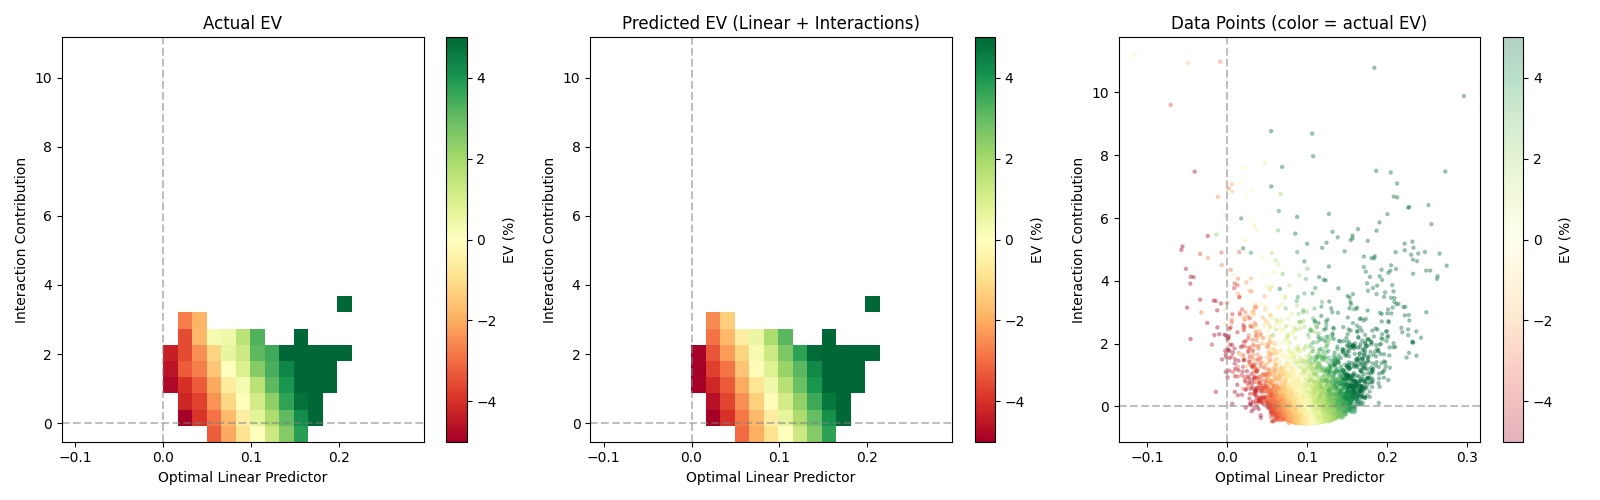


Interpretation:
- X-axis: How good the shoe looks to a linear model (like an optimal TC)
- Y-axis: Additional EV from card pair interactions
- If Y-axis shows vertical color gradient: interactions matter for prediction
- If color only varies horizontally: linear model is sufficient


In [ ]:
# Visualize using REGRESSION COEFFICIENTS as axes
# Axis 1: Optimal linear predictor (projection onto regression weights)
# Axis 2: What INTERACTIONS add beyond linear (captures non-linear effects)

# Axis 1: Projection onto optimal regression weights (best LINEAR predictor of EV)
optimal_weights = reg_prop.coef_  # From simple linear regression on proportions
optimal_weights_normalized = optimal_weights / np.linalg.norm(optimal_weights)
axis1 = X_prop @ optimal_weights_normalized  # "Optimal True Count"

# Axis 2: INTERACTION CONTRIBUTION
# This is what the Linear+Interactions model predicts BEYOND the simple linear model
# i.e., the non-linear part that can't be captured by any linear combination
poly_inter = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_inter = poly_inter.fit_transform(X_prop)
reg_inter = LinearRegression()
reg_inter.fit(X_inter, y)
y_pred_inter = reg_inter.predict(X_inter)

y_pred_linear = reg_prop.predict(X_prop)
axis2 = y_pred_inter - y_pred_linear  # What interactions add

print("Axis Definitions")
print("=" * 70)
print("\nAxis 1: 'Optimal Linear Predictor' (projection onto regression weights)")
print("  Best possible linear combination of card proportions for predicting EV")
print("  Weights (per card proportion):")
for card, w in zip(card_labels, optimal_weights_normalized):
    print(f"    {card}: {w:+.3f}")

print(f"\nAxis 2: 'Interaction Contribution'")
print("  = (Linear+Interactions prediction) - (Linear prediction)")
print("  This is the NON-LINEAR component that captures card pair synergies")
print(f"  Range: [{axis2.min():.2f}, {axis2.max():.2f}]")
print(f"  Std: {axis2.std():.3f}")

print(f"\nCorrelation between axes: {np.corrcoef(axis1, axis2)[0,1]:.3f}")
print("(Not necessarily 0 - interactions can correlate with linear effects)")

# How much does Axis 2 matter?
residual_linear = y - y_pred_linear
residual_inter = y - y_pred_inter
print(f"\nVariance explained:")
print(f"  Linear model R²:              {reg_prop.score(X_prop, y):.4f}")
print(f"  Linear+Interactions R²:       {reg_inter.score(X_inter, y):.4f}")
print(f"  Improvement from interactions: {reg_inter.score(X_inter, y) - reg_prop.score(X_prop, y):.4f}")

# Create heatmaps
fig, axes_arr = plt.subplots(1, 3, figsize=(16, 5))
n_bins = 25

# Plot 1: Actual EV
ax1 = axes_arr[0]
h1, xedges, yedges = np.histogram2d(axis1, axis2, bins=n_bins, weights=y)
counts, _, _ = np.histogram2d(axis1, axis2, bins=n_bins)
mean_ev = np.divide(h1, counts, where=counts > 5)
mean_ev[counts <= 5] = np.nan

im1 = ax1.imshow(mean_ev.T, origin='lower', aspect='auto',
                  extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                  cmap='RdYlGn', vmin=-5, vmax=5)
ax1.set_xlabel('Optimal Linear Predictor')
ax1.set_ylabel('Interaction Contribution')
ax1.set_title('Actual EV')
ax1.axhline(0, color='grey', linestyle='--', alpha=0.5)
ax1.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.colorbar(im1, ax=ax1, label='EV (%)')

# Plot 2: Predicted EV (from Linear+Interactions)
ax2 = axes_arr[1]
h2, _, _ = np.histogram2d(axis1, axis2, bins=n_bins, weights=y_pred_inter)
mean_ev_pred = np.divide(h2, counts, where=counts > 5)
mean_ev_pred[counts <= 5] = np.nan

im2 = ax2.imshow(mean_ev_pred.T, origin='lower', aspect='auto',
                  extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                  cmap='RdYlGn', vmin=-5, vmax=5)
ax2.set_xlabel('Optimal Linear Predictor')
ax2.set_ylabel('Interaction Contribution')
ax2.set_title('Predicted EV (Linear + Interactions)')
ax2.axhline(0, color='grey', linestyle='--', alpha=0.5)
ax2.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.colorbar(im2, ax=ax2, label='EV (%)')

# Plot 3: Scatter showing data distribution
ax3 = axes_arr[2]
scatter = ax3.scatter(axis1, axis2, c=y, cmap='RdYlGn', vmin=-5, vmax=5, alpha=0.3, s=5)
ax3.set_xlabel('Optimal Linear Predictor')
ax3.set_ylabel('Interaction Contribution')
ax3.set_title('Data Points (color = actual EV)')
ax3.axhline(0, color='grey', linestyle='--', alpha=0.5)
ax3.axvline(0, color='grey', linestyle='--', alpha=0.5)
plt.colorbar(scatter, ax=ax3, label='EV (%)')

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- X-axis: How good the shoe looks to a linear model (like an optimal TC)")
print("- Y-axis: Additional EV from card pair interactions")
print("- If Y-axis shows vertical color gradient: interactions matter for prediction")
print("- If color only varies horizontally: linear model is sufficient")